In [1]:
'''
Empirical Beam Hardening Correction (EBHC) to correct the calcium
'''

'\nEmpirical Beam Hardening Correction (EBHC) to correct the calcium\n'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy.optimize
import SimpleITK as sitk

import pcct_md_diffusion.utils as utils
from pcct_md_diffusion.fbp import additional_fbp_filter
from pcct_md_diffusion.utils import load_nist_attenuation, load_mixture_attenuation_from_composition_file
from pcct_md_diffusion.locations import base_input_dir

In [4]:
# load material attenuation data
min_kev = 30
max_kev = 120
kev_step = 1
kevs = np.arange(min_kev, max_kev + 1, kev_step)

df_att, dict_density = load_mixture_attenuation_from_composition_file(
    os.path.join(base_input_dir, 'omnitom_pcd/calibration/material_composition.csv'),
    os.path.join(base_input_dir, 'spectrum/NIST'),
    kevs=kevs,
    return_density=True
)

df_water = load_nist_attenuation(
    os.path.join(base_input_dir, 'spectrum/NIST/water.txt'),
    kevs=kevs
)

df_att['true_water'] = df_water['mu']
dict_density['true_water'] = 1.0

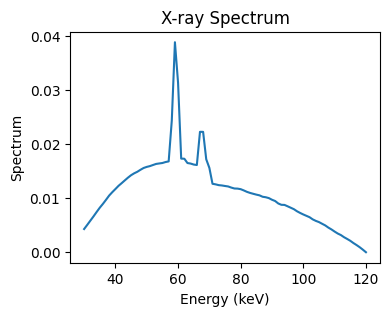

In [5]:
# load spectrum
df_spec = pd.read_csv(os.path.join(base_input_dir, 'spectrum/xray/spektr_120kVp_Be2p0_Cu0p127_omnitom.csv'))
df_spec = df_spec[(df_spec['Energy_keV'] >= min_kev) & (df_spec['Energy_keV'] <= max_kev)].reset_index(drop=True)
spectrum = df_spec['Photons'].values
spectrum = spectrum / np.sum(spectrum)  # normalize to sum to 1

df_spec = pd.DataFrame({
    'energy': df_spec['Energy_keV'],
    'spectrum': spectrum
})

plt.figure(figsize=(4, 3))
plt.plot(df_spec['energy'], df_spec['spectrum'])
plt.xlabel('Energy (keV)')
plt.ylabel('Spectrum')
plt.title('X-ray Spectrum')
plt.show()

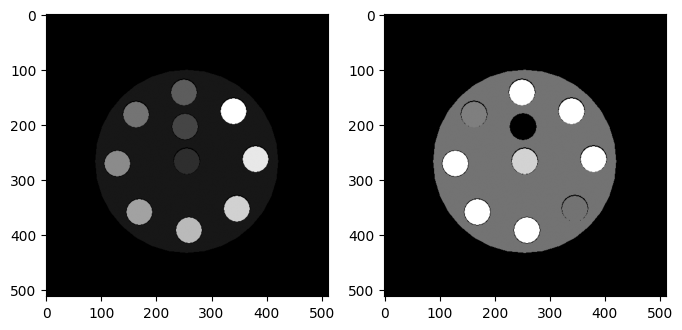

In [32]:
# load phantom
calibration_dir = os.path.join(base_input_dir, 'omnitom_pcd/calibration/calibration_8_41/img/1')
sitk_mask = sitk.ReadImage(os.path.join(calibration_dir, 'segmentation.seg.nrrd'))
dx, dy, dz = sitk_mask.GetSpacing()
mask = sitk.GetArrayFromImage(sitk_mask)[[0]]

# load phantom material labels
df_mask = pd.read_csv(os.path.join(calibration_dir, 'materials.csv'))

# compose a 60keV phantom
img_mono_60 = np.zeros_like(mask, dtype=np.float32)
for _, row in df_mask.iterrows():
    label = row['Seg']
    material = row['Material']
    mu = df_att[df_att['energy'] == 60][material].values[0]
    img_mono_60[mask == label] = mu

# water attenuation at 60keV
mu_water_60 = df_att[df_att['energy'] == 60]['true_water'].values[0]
mu_water = 0.0196
display_vmin = (-50 + 1000) / 1000 * mu_water
display_vmax = (50 + 1000) / 1000 * mu_water

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(mask[0], 'gray')

plt.subplot(1, 2, 2)
plt.imshow(img_mono_60[0], 'gray', vmin=mu_water_60-0.001, vmax=mu_water_60 + 0.001)
plt.show()

In [33]:
# load geometry
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
geometry_path = os.path.join(base_input_dir, 'omnitom_pcd/geometry/omnitom_3x3_parallel_fov_308.cfg')
geo = utils.load_geometry(geometry_path)
geo.nx = mask.shape[-1]
geo.ny = mask.shape[-2]
geo.nz = mask.shape[-3]
geo.nv = geo.nz
geo.dx = dx
geo.dy = dy
geo.dz = dz
geo.dv = dz
leapct = utils.set_leapct_geometry(geo)
# geo.nu *= 2
# geo.du /= 2
# geo.nview = 720
# geo.off_u = 0
# leapct = utils.set_leapct_geometry(geo, angles_in_deg=np.arange(0, 180, 180.0 / geo.nview).astype(np.float32))
leapct.print_parameters()


======== CT Parallel-Beam Geometry ========
number of angles: 1440
number of detector elements (rows, cols): 1 x 878
angular range: 360.000000 degrees
detector pixel size: 5.656000 mm x 0.351570 mm
center detector pixel: 0.000000, 445.750000

======== CT Volume ========
number of voxels (x, y, z): 512 x 512 x 1
voxel size: 0.601562 mm x 0.601562 mm x 5.656000 mm
FOV: [-154.000000, 154.000000] x [-154.000000, 154.000000] x [-2.828000, 2.828000]

======== Processing Settings ========
GPU processing on device 0
GPU with least amount of memory: 35.161964 GB



True

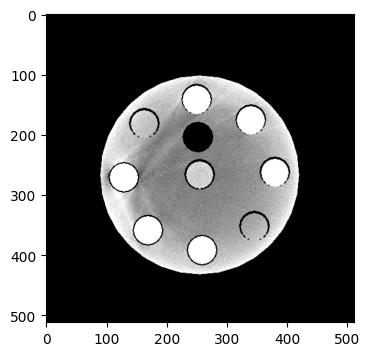

In [34]:
# forward project each material and make the ploychromatic projection
current_fp = leapct.allocate_projections()
prjs_materials = []
for i in range(len(df_mask)):
    label = df_mask.loc[i, 'Seg']
    material = df_mask.loc[i, 'Material']
    img_material = np.where(mask == label, 1, 0).astype(np.float32)
    _ = leapct.project(current_fp, img_material)
    prjs_materials.append(current_fp.copy())
prjs_materials = np.array(prjs_materials)

# the attenuation coefficient of each material at each energy
mus_materials = []
for i in range(len(df_mask)):
    material = df_mask.loc[i, 'Material']
    mus_materials.append(df_att[material].values)
mus_materials = np.array(mus_materials)

# composite the polychromatic projection
attenuation = np.sum(prjs_materials[..., None] * mus_materials[:, None, None, None, :], axis=0)
prjs = -np.log(np.sum(spectrum * np.exp(-attenuation), axis=-1)).astype(np.float32)

recon_poly = leapct.FBP(prjs)
plt.figure(figsize=(4, 4))
plt.imshow(recon_poly[0], 'gray', vmin=display_vmin, vmax=display_vmax)

In [35]:
def water_bhc_calibration(att_water, spectrum, mu_water, max_thickness=300, poly_order=3):
    thicknesses = np.linspace(0, max_thickness, 100)
    attenuation = att_water * thicknesses[:, None]
    prjs = -np.log(np.sum(spectrum * np.exp(-attenuation), axis=-1))
    prjs[prjs < 0] = 0

    # use polynomial fit without intercept
    A = np.vstack([prjs**i for i in range(1, poly_order + 1)]).T
    b = mu_water * thicknesses
    coeffs = np.linalg.lstsq(A, b, rcond=None)[0]
    return coeffs


def apply_water_bhc(prjs, coeffs):
    return np.sum([coeffs[i] * prjs**(i + 1) for i in range(len(coeffs))], axis=0).astype(np.float32)

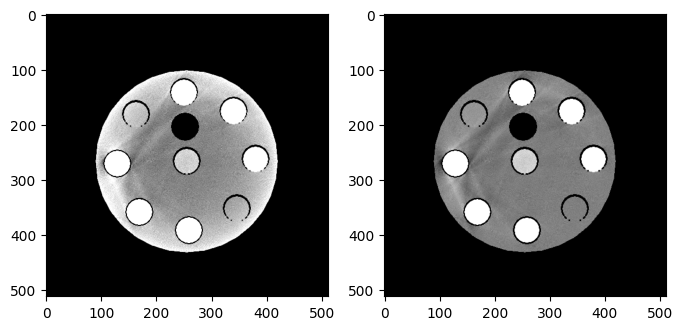

In [36]:
# water BHC with 30 cm water equivalent path length
bhc_water_coeffs = water_bhc_calibration(df_att['water'].values, spectrum, mu_water, max_thickness=300, poly_order=3)

# apply to the polychromatic projection
prjs_bhc_water = apply_water_bhc(prjs, bhc_water_coeffs)
prjs_bhc_water = additional_fbp_filter(prjs_bhc_water)
recon_bhc_water = leapct.FBP(prjs_bhc_water)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(recon_poly[0], cmap='gray', vmin=display_vmin, vmax=display_vmax)
plt.subplot(1, 2, 2)
plt.imshow(recon_bhc_water[0], cmap='gray', vmin=display_vmin, vmax=display_vmax)

In [ ]:
# ebhc with assumed calcium projection and water projection
# first get the expected calcium300 attenuation coefficient. It should be at the same kev with the water mu
effective_kev = np.interp(mu_water, df_att['water'].values[::-1], df_att['energy'].values[::-1])
mu_calcium_300 = np.interp(effective_kev, df_att['energy'].values, df_att['calcium_300'].values)
print('Effective energy for water mu: {:.2f} keV, corresponding calcium300 mu: {:.4f}'.format(effective_kev, mu_calcium_300))

thicknesses_water = np.linspace(0, 250, 100)
thicknesses_calcium = np.linspace(0, 100, 100)

prjs_water = -np.log(np.sum(spectrum * np.exp(-df_att['water'].values * thicknesses_water[:, None]), axis=-1))
prjs_calcium = -np.log(np.sum(spectrum * np.exp(-df_att['calcium_300'].values * thicknesses_calcium[:, None]), axis=-1))

prjs_water[prjs_water < 0] = 0
prjs_calcium[prjs_calcium < 0] = 0

thicknesses = np.array([[t_water, t_calcium] for t_water in thicknesses_water for t_calcium in thicknesses_calcium])
prjs_linearized = thicknesses[:, 0] * mu_water + thicknesses[:, 1] * mu_calcium_300
prjs_input = np.array([[prj_water, prj_calcium] for prj_water in prjs_water for prj_calcium in prjs_calcium])

Effective energy for water mu: 66.86 keV, corresponding calcium300 mu: 0.0388
